# Shein Review Data Exploration
EDA on the processed dataset (cleaned text, VADER sentiment, BERTopic topics). Run from the `notebooks/` folder.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/sample_processed.csv')
print(df.shape)
df[['content', 'score', 'sentiment', 'topic_label']].head()

(5000, 10)


                                             content  ...                topic_label
0  Sometime really good quality and fit some are ...  ...        Sizing & Fit Issues
1  I reviewed my products right after receiving m...  ...                        NaN
2  Good quality..many options but 4 stars I gave ...  ...  Miscellaneous/Unclustered
3  Great and reliable app. The clothing items are...  ...  Miscellaneous/Unclustered
4  Too many text alerts.... I attempted the suppo...  ...  Miscellaneous/Unclustered

[5 rows x 4 columns]

In [2]:
print('Missing values per column:')
print(df.isna().sum())
print('Duplicate review texts:', df['content'].duplicated().sum())

Missing values per column:
reviewId            0
content             0
score               0
thumbsUpCount       0
at                  0
clean_text          3
sentiment           0
topic_id            0
topic_label      1079
is_complaint        0
dtype: int64
Duplicate review texts: 0


`topic_label` is empty for reviews in BERTopic topics 19 and above, which were never given a name in `topic_modeling.py`.

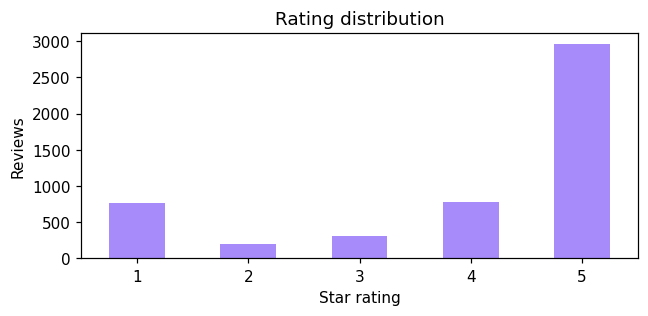

score
1     768
2     190
3     305
4     775
5    2962
Name: count, dtype: int64

In [3]:
ratings = df['score'].value_counts().sort_index()
ax = ratings.plot(kind='bar', color='#a78bfa', figsize=(6, 3))
ax.set_xlabel('Star rating')
ax.set_ylabel('Reviews')
ax.set_title('Rating distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
ratings

In [4]:
df['word_count'] = df['content'].str.split().str.len()
df['word_count'].describe().round(1)

count    5000.0
mean       39.9
std        22.0
min         3.0
25%        24.0
50%        34.0
75%        51.0
max       177.0
Name: word_count, dtype: float64

In [5]:
# Sentiment as stored in the CSV (VADER on clean_text)
df['sentiment'].value_counts()

sentiment
positive    4072
negative     809
neutral      119
Name: count, dtype: int64

## Validating VADER against star ratings
Star rating is used as a ground-truth proxy: 1-2 negative, 3 neutral, 4-5 positive.

In [6]:
def star_sentiment(score):
    return 'negative' if score <= 2 else ('neutral' if score == 3 else 'positive')

df['star_sentiment'] = df['score'].apply(star_sentiment)
agreement = (df['sentiment'] == df['star_sentiment']).mean() * 100
print(f'VADER agrees with the star rating on {agreement:.1f}% of reviews')
low = df[df['score'] <= 2]
print(f"1-2 star reviews labeled positive by VADER: {(low['sentiment'] == 'positive').sum()} of {len(low)}")
pd.crosstab(df['score'], df['sentiment'])

VADER agrees with the star rating on 84.1% of reviews
1-2 star reviews labeled positive by VADER: 284 of 958


sentiment  negative  neutral  positive
score                                 
1               531       48       189
2                83       12        95
3                81       13       211
4                64       13       698
5                50       33      2879

In [7]:
counts = df['star_sentiment'].value_counts()
print((counts / len(df) * 100).round(1))
print('Net sentiment score:', round((counts['positive'] - counts['negative']) / len(df) * 100, 1))
counts

star_sentiment
positive    74.7
negative    19.2
neutral      6.1
Name: count, dtype: float64
Net sentiment score: 55.6


star_sentiment
positive    3737
negative     958
neutral      305
Name: count, dtype: int64

In [8]:
print('BERTopic outliers (topic -1):', (df['topic_id'] == -1).sum())
print('Reviews in unnamed topics (id 19+):', df['topic_label'].isna().sum())
df['topic_label'].value_counts().head(10)

BERTopic outliers (topic -1): 1764
Reviews in unnamed topics (id 19+): 1079


topic_label
Miscellaneous/Unclustered                 1764
General Positive - Shopping Experience     688
General Positive - App Love                228
Refund & Order Complaints                  156
Shipping - Positive                        122
Quality & Fabric Issues                    108
Sizing & Fit Issues                        106
Sizing - Plus Size                          82
Shipping - Fast Delivery Praise             76
General Positive - Best App                 71
Name: count, dtype: int64

In [9]:
labeled = df[df['topic_label'].notna() & (df['topic_id'] != -1)]
(labeled.groupby('topic_label')['star_sentiment']
        .agg(reviews='size', pct_negative=lambda s: round((s == 'negative').mean() * 100, 1))
        .sort_values('reviews', ascending=False)
        .head(8))

                                        reviews  pct_negative
topic_label                                                  
General Positive - Shopping Experience      688           8.3
General Positive - App Love                 228           6.6
Refund & Order Complaints                   156          83.3
Shipping - Positive                         122           6.6
Quality & Fabric Issues                     108          13.9
Sizing & Fit Issues                         106           9.4
Sizing - Plus Size                           82           3.7
Shipping - Fast Delivery Praise              76           7.9

In [10]:
from collections import Counter

stop = set('a about after all also am an and any app are as at be because been but by can could did do does don even every for from get got had has have he her here him his how i if in is it its just like me more most much my no not now of on one only or other our out over really so some than that the their them then there these they this to too up us very was we were what when which who will with would you your shein s t m ve order orders item items ordered'.split())
words = Counter(w for t in df.loc[df['score'] <= 2, 'clean_text'].dropna()
                for w in t.split() if len(w) > 2 and w not in stop)
pd.DataFrame(words.most_common(10), columns=['word', 'count'])

       word  count
0  customer    257
1   service    251
2      time    171
3     money    162
4     never    155
5     still    150
6    refund    142
7   clothes    139
8    return    134
9  shipping    124